In [1]:
import ast
import matplotlib.pyplot as plt
import pandas as pd 
from datasets import load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
df_DA_US=df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')].copy()

In [3]:
df_DA_US=df_DA_US.dropna(subset='salary_year_avg')

<Axes: >

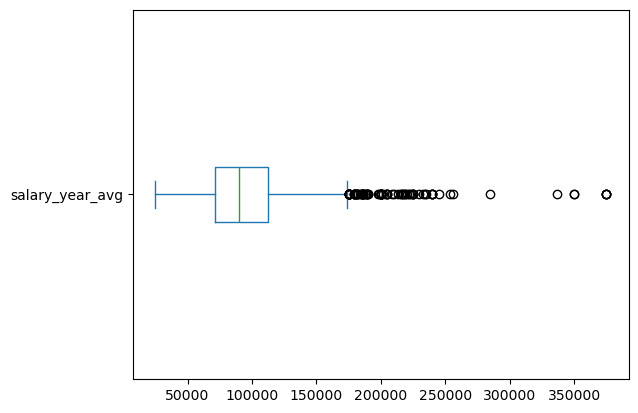

In [5]:
df_DA_US['salary_year_avg'].plot(kind='box',vert=False)

C:\Users\sandr\AppData\Local\Temp\ipykernel_8676\54391963.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list,labels=job_titles,vert=False)


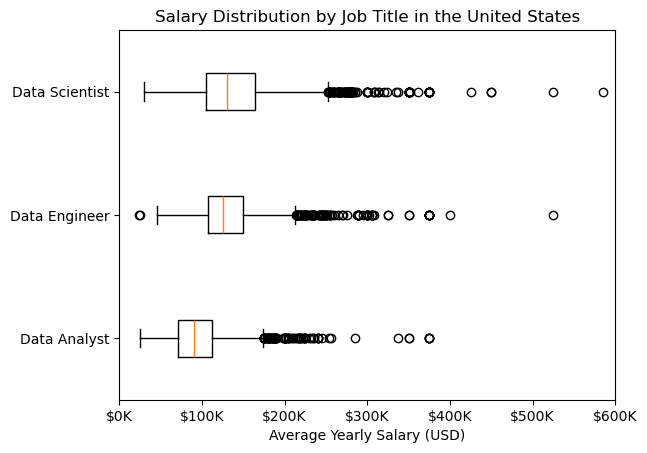

In [17]:
job_titles=['Data Analyst','Data Engineer','Data Scientist']
df_US=df[(df['job_country']=='United States') & (df['job_title_short'].isin(job_titles))].copy()
df_US.dropna(subset='salary_year_avg',inplace=True)
job_list=[df_US[df_US['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]
plt.boxplot(job_list,labels=job_titles,vert=False)
plt.title('Salary Distribution by Job Title in the United States')
plt.xlabel('Average Yearly Salary (USD)')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, post: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()

[109        89000.0
 180        90250.0
 410       133285.0
 988        62623.0
 1413       71300.0
             ...   
 782637     70000.0
 782798    111175.0
 783588    125000.0
 783866    115000.0
 784882     87500.0
 Name: salary_year_avg, Length: 4350, dtype: float64,
 92        120000.0
 146       129500.0
 307       185000.0
 339       195000.0
 380        97500.0
             ...   
 783111    125000.0
 784102     90000.0
 784191    217500.0
 785624    139216.0
 785641    150000.0
 Name: salary_year_avg, Length: 2915, dtype: float64,
 100       228222.0
 116       114000.0
 257       103128.0
 450       157500.0
 1257       70700.0
             ...   
 785324    234500.0
 785488    115000.0
 785563    136400.0
 785648    221875.0
 785692    157500.0
 Name: salary_year_avg, Length: 4553, dtype: float64]